# Perceptron simple: classifieur binaire


In [ ]:
import numpy as np


# Step 1: Defining our activation function
def sigmoid(x):
  return 1/(1+np.exp(-x))


# Derivative for the sigmoid (for backprop):
def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))



# Step2: Initializing our perceptron class
class Perceptron():
  def __init__(self, input_size, learning_rate=0.01):
    # Initialize weights adn bias
    self.weights = np.random.rand(input_size)
    self.bias = np.random.rand(1)
    self.learning_rate = learning_rate

  def forward(self, x):
    # calculate weighted sum
    linear_output = np.dot(x, self.weights) + self.bias
    # Apply activation function
    activation_function = sigmoid(linear_output)
    return activation_function


  def backward(self, x, x_pred, y_pred):
    # calculate the error (gradient of the loss function w.r.t (WITH RESPECT TO) the prediction)
    error = y_pred = x_pred

    # gradient of the loss w.r.t weights and bias
    weight_gradient = error* sigmoid_derivative(np.dot(x, self.weights) + self.bias) * x
    bias_gradient = error * sigmoid_derivative(np.dot(x, self.weights) + self.bias)

    # update weights and bias using gradients
    self.weights -= self.learning_rate * weight_gradient
    self.bias -= self.learning_rate * bias_gradient



  def train(self, x_train, y_train, epochs=10):
    for epoch in range(epochs):
      for x, y in zip(x_train, y_train):
        # forward pass
        y_pred = self.forward(x)

        # backward pass
        self.backward(x, y, y_pred)


      if epoch % (epochs // 5) == 0:
        loss = np.mean((y_train - self.predict(x_train)) ** 2)
        print(f'Epoch {epoch}, loss: {loss}')

  # prediction function (for testing after training)
  def predict(self, x_test):
    predictions = [self.forward(x) for x in x_test]
    return np.round(predictions) # round to 0 or 1 for binary classification

In [ ]:
# Define the XOR dataset
x_train = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_train = np.array([0, 1, 1, 0])  # Expected output for XOR

In [ ]:
# Initialize perceptron
perceptron = Perceptron(input_size=2, learning_rate=0.1)

# Train the perceptron
perceptron.train(x_train, y_train, epochs=100)

# Test predictions
print("Predictions on training data:", perceptron.predict(x_train))

Epoch 0, loss: 0.5
Epoch 20, loss: 0.5
Epoch 40, loss: 0.5
Epoch 60, loss: 0.5
Epoch 80, loss: 0.5
Predictions on training data: [[0.]
 [0.]
 [0.]
 [0.]]


In [ ]:
# Sample data (AND logic gate)
x_train = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_train = np.array([0, 0, 0, 1])  # Output for AND operation

# Initialize perceptron
perceptron = Perceptron(input_size=2, learning_rate=0.1)

# Train the perceptron
perceptron.train(x_train, y_train, epochs=100)

# Test predictions
print("Predictions on training data:", perceptron.predict(x_train))

Epoch 0, loss: 0.75
Epoch 20, loss: 0.75
Epoch 40, loss: 0.25
Epoch 60, loss: 0.25
Epoch 80, loss: 0.25
Predictions on training data: [[0.]
 [0.]
 [0.]
 [0.]]




---
# **Multi-Layer Perceptron (MLP): 2-layer MLP**


---



In [ ]:
import numpy as np

# ReLU activation function and its derivative
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

class TwoLayerMLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.001):
        # Initialize weights and biases for two layers
        self.weights_input_hidden = np.random.randn(input_size, hidden_size)
        self.bias_hidden = np.zeros(hidden_size)
        self.weights_hidden_output = np.random.randn(hidden_size, output_size)
        self.bias_output = np.zeros(output_size)
        self.learning_rate = learning_rate

    def forward(self, x):
        # Input to hidden layer
        self.hidden_input = np.dot(x, self.weights_input_hidden) + self.bias_hidden
        self.hidden_output = relu(self.hidden_input)  # Apply ReLU activation

        # Hidden to output layer
        self.final_input = np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output
        self.final_output = sigmoid(self.final_input)  # Apply sigmoid for binary output
        return self.final_output

    def backward(self, x, y_true, y_pred):
        # Calculate output layer error and gradient
        output_error = y_pred - y_true
        output_delta = output_error * sigmoid_derivative(self.final_input)

        # Calculate hidden layer error and gradient
        hidden_error = output_delta.dot(self.weights_hidden_output.T)
        hidden_delta = hidden_error * relu_derivative(self.hidden_input)

        # Update weights and biases (output layer)
        self.weights_hidden_output -= self.learning_rate * np.outer(self.hidden_output, output_delta)
        self.bias_output -= self.learning_rate * output_delta

        # Update weights and biases (hidden layer)
        self.weights_input_hidden -= self.learning_rate * np.outer(x, hidden_delta)
        self.bias_hidden -= self.learning_rate * hidden_delta

    def train(self, x_train, y_train, epochs=10):
        for epoch in range(epochs):
            for x, y in zip(x_train, y_train):
                y_pred = self.forward(x)
                self.backward(x, y, y_pred)
            if epoch % (epochs // 5) == 0:
                loss = np.mean((y_train - self.predict(x_train))**2)
                print(f"Epoch {epoch}, Loss: {loss}")

    def predict(self, x_test):
        predictions = [self.forward(x) for x in x_test]
        return np.round(predictions)



In [ ]:
# XOR training data
x_train = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_train = np.array([0, 1, 1, 0])  # Output for XOR operation

# Initialize and train the Two-Layer MLP
mlp = TwoLayerMLP(input_size=2, hidden_size=4, output_size=1, learning_rate=0.1)
mlp.train(x_train, y_train, epochs=5000)

# Evaluate on the training data
predictions = mlp.predict(x_train)
print("Predictions on XOR dataset:", predictions)


Epoch 0, Loss: 0.5
Epoch 1000, Loss: 0.5
Epoch 2000, Loss: 0.5
Epoch 3000, Loss: 0.5
Epoch 4000, Loss: 0.5
Predictions on XOR dataset: [[0.]
 [0.]
 [1.]
 [0.]]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define a simple neural network with PyTorch
class SimpleANN(nn.Module):
    def __init__(self):
        super(SimpleANN, self).__init__()
        # Define the layers
        self.hidden = nn.Linear(2, 4)  # Input size 2, hidden size 4
        self.output = nn.Linear(4, 1)  # Hidden size 4, output size 1

    def forward(self, x):
        # Forward pass with ReLU and Sigmoid
        x = torch.nn.functional.leaky_relu(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x

# Initialize the model, loss function, and optimizer
model = SimpleANN()
criterion = nn.BCELoss()  # Binary Cross Entropy for binary classification
optimizer = optim.SGD(model.parameters(), lr=0.06)

# Prepare the data as PyTorch tensors
x_train = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
y_train = torch.tensor([[0], [1], [1], [0]], dtype=torch.float32)

# Training loop
epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()  # Zero the gradients
    outputs = model(x_train)  # Forward pass
    loss = criterion(outputs, y_train)  # Calculate loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update weights

    # Print loss occasionally
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Evaluate the model on training data
with torch.no_grad():
    predictions = model(x_train)
    print("Predictions on XOR dataset:", torch.round(predictions))


Epoch 0, Loss: 0.7009411454200745
Epoch 1000, Loss: 0.041600003838539124
Epoch 2000, Loss: 0.011655807495117188
Epoch 3000, Loss: 0.006093062926083803
Epoch 4000, Loss: 0.003966697957366705
Predictions on XOR dataset: tensor([[0.],
        [1.],
        [1.],
        [0.]])





---

# **avec Tensorflow + Keras API**

---



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np



# Define the XOR dataset
x_train = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_train = np.array([0, 1, 1, 0])  # Expected output for XOR



# Build a simple 2-layer MLP model
model = Sequential([
    Dense(4, input_shape=(2,), activation='relu'),  # Hidden layer with 4 neurons and ReLU
    Dense(1, activation='sigmoid')  # Output layer with 1 neuron and sigmoid activation
])


# Compile the model
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])


# Train the model
model.fit(x_train, y_train, epochs=1000, verbose=0)


# Make predictions
predictions = model.predict(x_train)
print("Predictions:", np.round(predictions).flatten())


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predictions: [0. 1. 0. 0.]




---

# Début TP/LAB Digit Recongnition - MNIST - M. Slim M'**HIRI**


---



In [ ]:
!pip install tensorflow keras np_utils

In [ ]:
import keras

from keras.datasets import mnist
from keras.utils import to_categorical
from keras import layers


def baseline_model(num_pixels, num_classes):

    #TODO - Application 1 - Step 6a - Initialize the sequential model
   # model = None   # Modify this
    model = keras.models.Sequential()

    #TODO - Application 1 - Step 6b - Define a hidden dense layer with 8 neurons
    model.add(layers.Dense(8, input_dim=num_pixels, kernel_initializer='normal', activation='relu'))

    #TODO - Application 1 - Step 6c - Define the output dense layer
    model.add(layers.Dense(num_classes, kernel_initializer='normal', activation='softmax'))

    # TODO - Application 1 - Step 6d - Compile the model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

In [ ]:
import numpy as np


# loading our data from mnist dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten the images into 784-element vectors
num_pixels = X_train.shape[1] * X_train.shape[2]
X_train = X_train.reshape((X_train.shape[0], num_pixels)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], num_pixels)).astype('float32')

# Normalize pixel values to the range [0, 1]
X_train, X_test = X_train / 255, X_test / 255

print(y_train)

[5 0 4 ... 5 6 8]


In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Loading data from the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten the images into 784-element vectors
num_pixels = X_train.shape[1] * X_train.shape[2]
X_train = X_train.reshape((X_train.shape[0], num_pixels)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], num_pixels)).astype('float32')

# Normalize pixel values to the range [0, 1]
X_train, X_test = X_train / 255, X_test / 255

# Convert labels to one-hot encoded format
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
num_classes = y_test.shape[1]  # This will be 10 for MNIST

print("Number of classes:", num_classes)
print("One-hot encoded labels (y_train[0]):", y_train[0])  # Example to check the output


Number of classes: 10
One-hot encoded labels (Y_train[0]): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the baseline model architecture
def baseline_model():
    model = Sequential()
    model.add(Dense(8, input_dim=num_pixels, kernel_initializer='normal', activation='relu'))
    model.add(Dense(num_classes, kernel_initializer='normal', activation='softmax'))

    # Compile the model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


In [ ]:
# Build the model
model = baseline_model()

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=200, verbose=2)


Epoch 1/100
300/300 - 2s - 6ms/step - accuracy: 0.6855 - loss: 1.1720 - val_accuracy: 0.8499 - val_loss: 0.5746
Epoch 2/100
300/300 - 1s - 4ms/step - accuracy: 0.8697 - loss: 0.4732 - val_accuracy: 0.8968 - val_loss: 0.3817
Epoch 3/100
300/300 - 1s - 4ms/step - accuracy: 0.8986 - loss: 0.3604 - val_accuracy: 0.9074 - val_loss: 0.3275
Epoch 4/100
300/300 - 1s - 5ms/step - accuracy: 0.9081 - loss: 0.3254 - val_accuracy: 0.9116 - val_loss: 0.3107
Epoch 5/100
300/300 - 1s - 4ms/step - accuracy: 0.9132 - loss: 0.3075 - val_accuracy: 0.9165 - val_loss: 0.3005
Epoch 6/100
300/300 - 1s - 2ms/step - accuracy: 0.9160 - loss: 0.2965 - val_accuracy: 0.9177 - val_loss: 0.2910
Epoch 7/100
300/300 - 1s - 3ms/step - accuracy: 0.9181 - loss: 0.2880 - val_accuracy: 0.9197 - val_loss: 0.2861
Epoch 8/100
300/300 - 1s - 4ms/step - accuracy: 0.9199 - loss: 0.2814 - val_accuracy: 0.9222 - val_loss: 0.2810
Epoch 9/100
300/300 - 2s - 7ms/step - accuracy: 0.9208 - loss: 0.2764 - val_accuracy: 0.9219 - val_loss:

In [79]:
# Evaluate on test data
scores = model.evaluate(X_test, y_test, verbose=0)
print("Baseline Error: {:.2f}%".format(100 - scores[1] * 100))


Baseline Error: 6.99%


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
300/300 - 38s - 125ms/step - accuracy: 0.8671 - loss: 0.4256 - val_accuracy: 0.9755 - val_loss: 0.0780
Epoch 2/10
300/300 - 40s - 132ms/step - accuracy: 0.9691 - loss: 0.0993 - val_accuracy: 0.9848 - val_loss: 0.0486
Epoch 3/10
300/300 - 42s - 139ms/step - accuracy: 0.9787 - loss: 0.0694 - val_accuracy: 0.9871 - val_loss: 0.0429
Epoch 4/10
300/300 - 42s - 139ms/step - accuracy: 0.9829 - loss: 0.0557 - val_accuracy: 0.9899 - val_loss: 0.0315
Epoch 5/10
300/300 - 40s - 132ms/step - accuracy: 0.9856 - loss: 0.0468 - val_accuracy: 0.9895 - val_loss: 0.0291
Epoch 6/10
300/300 - 34s - 112ms/step - accuracy: 0.9872 - loss: 0.0414 - val_accuracy: 0.9899 - val_loss: 0.0338
Epoch 7/10
300/300 - 35s - 117ms/step - accuracy: 0.9876 - loss: 0.0381 - val_accuracy: 0.9899 - val_loss: 0.0323
Epoch 8/10
300/300 - 33s - 111ms/step - accuracy: 0.9888 - loss: 0.0350 - val_accuracy: 0.9897 - val_loss: 0.0316
Epoch 9/10
300/300 - 42s - 141ms/step - accuracy: 0.9900 - loss: 0.0311 - val_accuracy: 

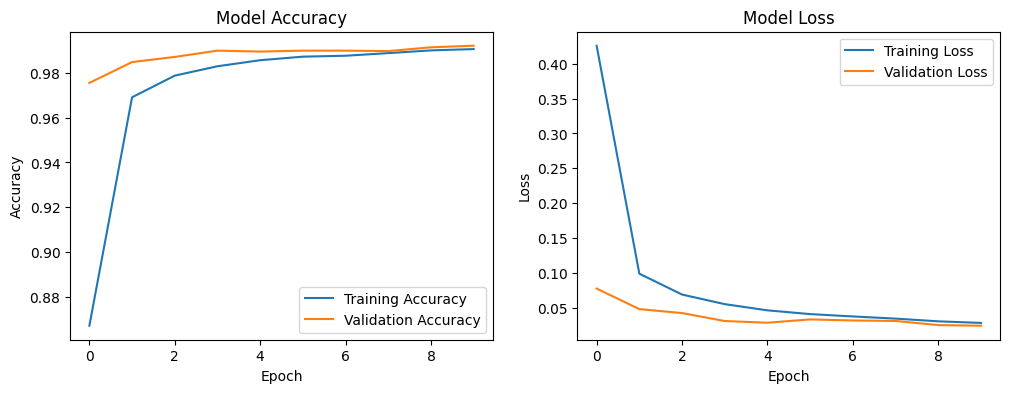

In [81]:
# Importing necessary libraries
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

# Loading and preprocessing the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32') / 255
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32') / 255
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
num_classes = y_test.shape[1]

# Building the model
model = Sequential()

# Layer 1: First convolutional layer with 30 filters of size 5x5
model.add(Conv2D(30, (5, 5), activation='relu', input_shape=(28, 28, 1)))

# Layer 2: First max pooling layer with a pool size of 2x2
model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 3: Second convolutional layer with 15 filters of size 3x3
model.add(Conv2D(15, (3, 3), activation='relu'))

# Layer 4: Second max pooling layer with a pool size of 2x2
model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 5: Dropout layer with a rate of 20%
model.add(Dropout(0.2))

# Layer 6: Flatten layer to reshape the 2D output to a 1D vector
model.add(Flatten())

# Layer 7: Fully connected layer with 128 neurons and ReLU activation
model.add(Dense(128, activation='relu'))

# Layer 8: Fully connected layer with 50 neurons and ReLU activation
model.add(Dense(50, activation='relu'))

# Layer 9: Output layer with 10 neurons (one per class) and softmax activation
model.add(Dense(num_classes, activation='softmax'))

# Compiling the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)

# Evaluating model performance
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plotting accuracy and loss history (optional but useful for reporting)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Model Accuracy")

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Model Loss")

plt.show()
